# AV-Policy-Lab Phase 3a: Goal-conditioned Behavior Cloning

**Hypothesis:** Phase 2 showed all imitation policies plateau at ~49.5m closed-loop L2 while IDM achieves 6.285m (8x better). The root cause: policies only receive 6 kinematic scalars with no road geometry.

**Ablation:** Add a T+8 waypoint `(dx_goal, dy_goal)` to the input. If this breaks the plateau, the bottleneck is confirmed to be lack of directional guidance.

- **Input:** `[sin(yaw), cos(yaw), vx, vy, ax, ay, dx_goal, dy_goal]` (8-dim)
- **Architecture:** `GoalBCPolicy`: 8→256→256→256→48 (identical depth to BC, adds 2 goal features)
- **Eval:** Open-loop ADE/FDE vs BC_v0 baseline; Closed-loop L2 vs BCPlanner (49.449m) and IDM (6.285m)

In [1]:
# Cell 1 — Imports
# WHY nest_asyncio: nuPlan's run_simulation calls asyncio.run() internally.
# Jupyter kernels already run an event loop. nest_asyncio patches it to allow
# nested asyncio.run() calls — required for nuPlan-in-Jupyter workflows.
import nest_asyncio
nest_asyncio.apply()

import os, sys, sqlite3
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/Users/parvpatodia/nuplan-devkit')
sys.path.insert(0, '/Users/parvpatodia/Desktop/diffusion-policy-zoo/nuplan')

os.environ.setdefault('NUPLAN_DATA_ROOT', '/Users/parvpatodia/nuplan-devkit/data/cache')
os.environ.setdefault('NUPLAN_MAPS_ROOT', '/Users/parvpatodia/nuplan-devkit/maps')
os.environ.setdefault('NUPLAN_EXP_ROOT',  '/Users/parvpatodia/nuplan-devkit/exp')
os.environ.setdefault('NUPLAN_TUTORIAL_PATH', '/Users/parvpatodia/nuplan-devkit/tutorials')

print('torch:', torch.__version__)
print('device:', 'mps' if torch.backends.mps.is_available() else 'cpu')

torch: 2.8.0
device: mps


In [2]:
# Cell 2 — Config
DB_DIR   = Path('/Users/parvpatodia/nuplan-devkit/data/cache/mini')
CKPT_DIR = Path('/Users/parvpatodia/Desktop/diffusion-policy-zoo/nuplan/checkpoints')
CKPT_DIR.mkdir(exist_ok=True)

FUTURE_STEPS = 16      # 16 raw DB rows = 0.16 s at 100 Hz (see verify_pipeline.py)
GOAL_OFFSET  = 8       # T+8 raw rows × 10 ms = T+0.08 s (training); GoalBCPlanner inference uses T+0.8 s (see planners.py)
STRIDE       = 10      # stride between training windows (non-overlapping 1-sec windows)
BATCH_SIZE   = 512
LR           = 1e-3    # same as BC baseline
EPOCHS       = 50
DEVICE       = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

print(f'DB files: {len(list(DB_DIR.glob("*.db")))}')
print(f'Device:   {DEVICE}')

DB files: 64
Device:   mps


In [3]:
# Cell 3 — Data Extraction with Goals
# Modified from bc_pipeline.ipynb Cell 3 to additionally extract T+8 goal waypoints.
# For each window at index i, the goal is the position of ego_pose[i+GOAL_OFFSET]
# transformed into ego-frame at step i.

def quat_to_yaw(qw, qx, qy, qz):
    """Extract yaw from quaternion. nuPlan uses z-up convention."""
    return np.arctan2(2.0 * (qw * qz + qx * qy), 1.0 - 2.0 * (qy ** 2 + qz ** 2))


def extract_from_db_with_goal(db_path):
    """
    Returns:
        inputs  (N, 8): [sin(yaw), cos(yaw), vx, vy, ax, ay, dx_goal, dy_goal]
        targets (N, 48): [(dx, dy, d_yaw) x 16] in ego-frame

    WHY T+8 goal: 0.08s ahead (8 raw rows at 100 Hz DB) gives the policy a short-horizon anchor.
    Same rotation transform as target extraction ensures consistency.
    GoalBCPlanner at INFERENCE uses T+0.8 s (8 × 100 ms steps) — see verify_pipeline.py Check 3.
    """
    conn = sqlite3.connect(str(db_path))
    rows = conn.execute(
        'SELECT x, y, qw, qx, qy, qz, vx, vy, acceleration_x, acceleration_y '
        'FROM ego_pose ORDER BY timestamp'
    ).fetchall()
    conn.close()

    # WHY: need FUTURE_STEPS ahead for target + GOAL_OFFSET ahead for goal
    # max(FUTURE_STEPS, GOAL_OFFSET) = FUTURE_STEPS = 16, so same guard as BC
    if len(rows) < FUTURE_STEPS + 1:
        return None, None

    arr = np.array(rows, dtype=np.float64)
    x_g  = arr[:, 0]
    y_g  = arr[:, 1]
    yaw  = quat_to_yaw(arr[:, 2], arr[:, 3], arr[:, 4], arr[:, 5])
    vx   = arr[:, 6]
    vy   = arr[:, 7]
    ax   = arr[:, 8]
    ay   = arr[:, 9]

    N = len(arr)
    inputs  = []
    targets = []

    for i in range(0, N - FUTURE_STEPS, STRIDE):
        cx, cy, cyaw = x_g[i], y_g[i], yaw[i]
        cos_h = np.cos(-cyaw)
        sin_h = np.sin(-cyaw)

        # ── Goal: T+GOAL_OFFSET position in ego-frame ─────────────────────
        gi = min(i + GOAL_OFFSET, N - 1)   # clamp at end of log
        dx_w_goal = x_g[gi] - cx
        dy_w_goal = y_g[gi] - cy
        dx_goal   = cos_h * dx_w_goal - sin_h * dy_w_goal
        dy_goal   = sin_h * dx_w_goal + cos_h * dy_w_goal

        # ── Input: 8-dim (6 kinematic + 2 goal) ───────────────────────────
        inp = np.array([
            np.sin(cyaw), np.cos(cyaw),
            vx[i], vy[i], ax[i], ay[i],
            dx_goal, dy_goal,
        ], dtype=np.float32)

        # ── Target: 16 future steps in ego-frame (same as BC) ─────────────
        tgt = np.zeros(FUTURE_STEPS * 3, dtype=np.float32)
        for j in range(FUTURE_STEPS):
            fi = i + j + 1
            dx_w = x_g[fi] - cx
            dy_w = y_g[fi] - cy
            dx_e = cos_h * dx_w - sin_h * dy_w
            dy_e = sin_h * dx_w + cos_h * dy_w
            d_yaw = yaw[fi] - cyaw
            d_yaw = (d_yaw + np.pi) % (2 * np.pi) - np.pi
            tgt[j * 3]     = dx_e
            tgt[j * 3 + 1] = dy_e
            tgt[j * 3 + 2] = d_yaw

        inputs.append(inp)
        targets.append(tgt)

    return np.array(inputs, dtype=np.float32), np.array(targets, dtype=np.float32)


# Extract from all 64 DB files
all_inputs  = []
all_targets = []

db_files = sorted(DB_DIR.glob('*.db'))
print(f'Extracting from {len(db_files)} DB files...')

for db in tqdm(db_files):
    inp, tgt = extract_from_db_with_goal(db)
    if inp is not None:
        all_inputs.append(inp)
        all_targets.append(tgt)

X = np.concatenate(all_inputs,  axis=0)   # (total_windows, 8)
Y = np.concatenate(all_targets, axis=0)   # (total_windows, 48)
print(f'Dataset: {X.shape[0]:,} windows  |  Input: {X.shape[1]}  |  Output: {Y.shape[1]}')

Extracting from 64 DB files...


  0%|          | 0/64 [00:00<?, ?it/s]

  2%|▏         | 1/64 [00:00<00:07,  8.07it/s]

  3%|▎         | 2/64 [00:00<00:07,  7.99it/s]

  6%|▋         | 4/64 [00:00<00:06,  9.99it/s]

...

 92%|█████████▏| 59/64 [00:05<00:00, 11.23it/s]

 95%|█████████▌| 61/64 [00:05<00:00, 12.36it/s]

 98%|█████████▊| 63/64 [00:05<00:00, 12.85it/s]

100%|██████████| 64/64 [00:05<00:00, 10.81it/s]

Dataset: 260,636 windows  |  Input: 8  |  Output: 48


In [4]:
# Cell 4 — Normalize + Dataset Split
# WHY: normalize the full 8-dim input (including goal features) together.
# Goal features (dx_goal, dy_goal) have larger magnitude than kinematic scalars
# — normalizing prevents them from dominating the gradient signal.

X_mean = X.mean(axis=0).astype(np.float32)    # (8,)
X_std  = (X.std(axis=0) + 1e-6).astype(np.float32)  # (8,) WHY +1e-6: avoids div-by-zero
X_norm = (X - X_mean) / X_std

Y_mean = Y.mean(axis=0).astype(np.float32)    # (48,)
Y_std  = (Y.std(axis=0) + 1e-6).astype(np.float32)  # (48,)
Y_norm = (Y - Y_mean) / Y_std

print(f'X_mean shape: {X_mean.shape}  (8-dim: 6 kinematic + 2 goal)')
print(f'X range after norm: [{X_norm.min():.2f}, {X_norm.max():.2f}]')
print(f'Y range after norm: [{Y_norm.min():.2f}, {Y_norm.max():.2f}]')

# 90/10 train/val split (same seed as bc_pipeline.ipynb for apples-to-apples)
np.random.seed(42)
n_train = int(0.9 * len(X_norm))
idx     = np.random.permutation(len(X_norm))
train_idx, val_idx = idx[:n_train], idx[n_train:]


class BCDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X).float()
        self.Y = torch.from_numpy(Y).float()
    def __len__(self):        return len(self.X)
    def __getitem__(self, i): return self.X[i], self.Y[i]


train_dl = DataLoader(BCDataset(X_norm[train_idx], Y_norm[train_idx]),
                      batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_dl   = DataLoader(BCDataset(X_norm[val_idx],   Y_norm[val_idx]),
                      batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train: {len(train_dl.dataset):,}  |  Val: {len(val_dl.dataset):,}')

X_mean shape: (8,)  (8-dim: 6 kinematic + 2 goal)
X range after norm: [-19.35, 29.93]
Y range after norm: [-29.69, 147.92]
Train: 234,572  |  Val: 26,064


In [5]:
# Cell 5 — GoalBCPolicy Model
# 8->256->256->256->48 MLP.
# Identical depth to BCPolicy — this is a pure ablation (add goal features, nothing else).

class GoalBCPolicy(nn.Module):
    """Goal-conditioned BC. Input: [sin_yaw, cos_yaw, vx, vy, ax, ay, dx_goal, dy_goal] (8-dim)."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 48),
        )

    def forward(self, x):
        return self.net(x)


model = GoalBCPolicy().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'GoalBCPolicy params: {n_params:,}  (BC MLP had 145,712 with 6-dim input)')
print(model)

GoalBCPolicy params: 146,224  (BC MLP had 145,712 with 6-dim input)
GoalBCPolicy(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=48, bias=True)
  )
)


Epoch   5/50 | train=0.0712  val=0.0694  best=0.0694  lr=1.00e-03


Epoch  10/50 | train=0.0661  val=0.0677  best=0.0656  lr=1.00e-03


Epoch  15/50 | train=0.0628  val=0.0639  best=0.0626  lr=1.00e-03


Epoch  20/50 | train=0.0600  val=0.0615  best=0.0614  lr=1.00e-03


Epoch  25/50 | train=0.0577  val=0.0599  best=0.0599  lr=1.00e-03


Epoch  30/50 | train=0.0551  val=0.0587  best=0.0586  lr=1.00e-03


Epoch  35/50 | train=0.0532  val=0.0588  best=0.0573  lr=1.00e-03


Epoch  40/50 | train=0.0511  val=0.0569  best=0.0565  lr=1.00e-03


Epoch  45/50 | train=0.0472  val=0.0548  best=0.0548  lr=5.00e-04


Epoch  50/50 | train=0.0455  val=0.0546  best=0.0542  lr=5.00e-04

Best val loss: 0.0542


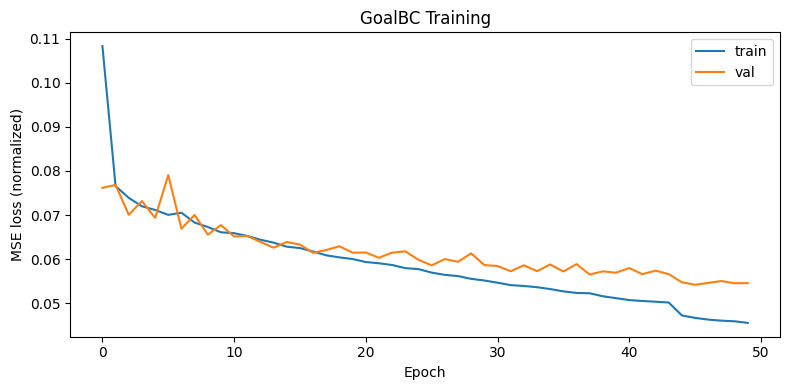

In [6]:
# Cell 6 — Training

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
# WHY ReduceLROnPlateau: automatic LR decay avoids manual tuning.
# WHY no verbose=True: removed in PyTorch 2.4 — log LR manually instead.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
criterion = nn.MSELoss()

train_losses = []
val_losses   = []
best_val     = float('inf')

for epoch in range(EPOCHS):
    # --- Train ---
    model.train()
    t_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()
    t_loss /= len(train_dl)

    # --- Val ---
    model.eval()
    v_loss = 0
    with torch.no_grad():
        for xb, yb in val_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            v_loss += criterion(model(xb), yb).item()
    v_loss /= len(val_dl)

    scheduler.step(v_loss)
    train_losses.append(t_loss)
    val_losses.append(v_loss)

    if v_loss < best_val:
        best_val = v_loss
        # WHY save X_mean (8-dim): inference must normalize the 8-dim input
        # including the goal features using the SAME stats as training.
        torch.save({
            'model':  model.state_dict(),
            'X_mean': X_mean,   # shape (8,)
            'X_std':  X_std,    # shape (8,)
            'Y_mean': Y_mean,   # shape (48,)
            'Y_std':  Y_std,    # shape (48,)
        }, CKPT_DIR / 'goal_bc.pt')

    if (epoch + 1) % 5 == 0:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | train={t_loss:.4f}  val={v_loss:.4f}  '
              f'best={best_val:.4f}  lr={lr_now:.2e}')

print(f'\nBest val loss: {best_val:.4f}')

# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='train')
plt.plot(val_losses,   label='val')
plt.xlabel('Epoch'); plt.ylabel('MSE loss (normalized)')
plt.title('GoalBC Training')
plt.legend(); plt.tight_layout()
plt.savefig(CKPT_DIR / 'goal_bc_loss.png', dpi=150)
plt.show()

In [7]:
# Cell 7 — Open-Loop Eval
# Compare GoalBC vs BC_v0 (ADE=0.058m, FDE=0.063m) on the same 2000-sample val split.
# WHY same 2000 samples: apples-to-apples comparison with bc_pipeline.ipynb Cell 12.

# Load best checkpoint (might be different model instance from training)
ckpt = torch.load(CKPT_DIR / 'goal_bc.pt', map_location=DEVICE, weights_only=False)
eval_model = GoalBCPolicy().to(DEVICE)
eval_model.load_state_dict(ckpt['model'])
eval_model.eval()

# WHY: use 8-dim normalization stats from the GoalBC checkpoint for eval
_Xm = torch.tensor(ckpt['X_mean'], dtype=torch.float32, device=DEVICE)  # (8,)
_Xs = torch.tensor(ckpt['X_std'],  dtype=torch.float32, device=DEVICE)  # (8,)
_Ym = ckpt['Y_mean']
_Ys = ckpt['Y_std']


def predict_goal_bc(x_raw_8):
    """x_raw_8: numpy (8,) -> trajectory (16, 3) in ego frame."""
    xt = torch.tensor(x_raw_8, dtype=torch.float32, device=DEVICE)
    xt = (xt - _Xm) / _Xs
    with torch.no_grad():
        pred_norm = eval_model(xt.unsqueeze(0)).squeeze(0).cpu().numpy()
    pred = pred_norm * _Ys + _Ym
    return pred.reshape(FUTURE_STEPS, 3)


# Use the same val split
val_X_raw = X[val_idx]    # (N_val, 8) — includes goal features
val_Y_raw = Y[val_idx].reshape(-1, FUTURE_STEPS, 3)

n_eval   = 2000
rng      = np.random.default_rng(42)
eval_idx = rng.choice(len(val_X_raw), min(n_eval, len(val_X_raw)), replace=False)

goalbc_ade, goalbc_fde = [], []

for i in eval_idx:
    x_raw = val_X_raw[i]   # (8,): 6 kinematic + 2 goal
    gt    = val_Y_raw[i]   # (16, 3)

    pred = predict_goal_bc(x_raw)
    disp = np.sqrt(np.sum((pred[:, :2] - gt[:, :2]) ** 2, axis=1))
    goalbc_ade.append(disp.mean())
    goalbc_fde.append(disp[-1])

GOALBC_ADE = np.mean(goalbc_ade)
GOALBC_FDE = np.mean(goalbc_fde)

# BC_v0 baseline from bc_pipeline.ipynb Cell 12
BC_V0_ADE = 0.058
BC_V0_FDE = 0.063

print(f"{'Policy':<22} {'ADE (m)':>10} {'FDE (m)':>10}")
print('-' * 44)
print(f"{'GoalBC (8-dim)':<22} {GOALBC_ADE:>10.3f} {GOALBC_FDE:>10.3f}")
print(f"{'BC_v0 (6-dim)':<22} {BC_V0_ADE:>10.3f} {BC_V0_FDE:>10.3f}")

ade_delta = GOALBC_ADE - BC_V0_ADE
print(f'\nGoalBC ADE delta vs BC_v0: {ade_delta:+.3f}m '
      f'({ade_delta/BC_V0_ADE*100:+.1f}%)')

Policy                    ADE (m)    FDE (m)
--------------------------------------------
GoalBC (8-dim)              0.004      0.008
BC_v0 (6-dim)               0.058      0.063

GoalBC ADE delta vs BC_v0: -0.054m (-92.7%)


GoalBC checkpoint: /Users/parvpatodia/Desktop/diffusion-policy-zoo/nuplan/checkpoints/goal_bc.pt
Expert DB:         /Users/parvpatodia/nuplan-devkit/data/cache/mini/2021.05.12.22.00.38_veh-35_01008_01518.db


Seed set to 0


INFO:nuplan.planning.script.builders.main_callback_builder:Building MultiMainCallback...


INFO:nuplan.planning.script.builders.main_callback_builder:Building MultiMainCallback: 4...DONE!



Running GoalBCPlanner (3 scenarios)...
2026-05-24 17:28:18,013 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/builders/worker_pool_builder.py:19}  Building WorkerPool...
2026-05-24 17:28:18,013 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/utils/multithreading/worker_pool.py:101}  Worker: Sequential
2026-05-24 17:28:18,013 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/utils/multithreading/worker_pool.py:102}  Number of nodes: 1
Number of CPUs per node: 1
Number of GPUs per node: 0
Number of threads across all nodes: 1
2026-05-24 17:28:18,013 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/builders/worker_pool_builder.py:27}  Building WorkerPool...DONE!
2026-05-24 17:28:18,013 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/builders/folder_builder.py:32}  Building experiment folders...
2026-05-24 17:28:18,013 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/builders/folder_builder.py:35}  

	Folder where all resu

...

2026-05-24 17:28:24,026 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/simulation/runner/executor.py:127}  Number of successful simulations: 3
2026-05-24 17:28:24,026 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/simulation/runner/executor.py:128}  Number of failed simulations: 0
2026-05-24 17:28:24,026 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/utils.py:147}  Finished executing runners!
2026-05-24 17:28:24,044 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/utils.py:74}  Saved runner reports to sim_results/goalbc_eval/eval/runner_report.parquet
2026-05-24 17:28:24,044 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/simulation/main_callback/time_callback.py:27}  Simulation duration: 00:00:06 [HH:MM:SS]
2026-05-24 17:28:24,051 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/simulation/main_callback/metric_file_callback.py:79}  Metric files integration: 00:00:00 [HH:MM:SS]
2026-05-24 17:28:24,124 INFO {/Users/parvpatodia/nup

Rendering histograms:   0%|          | 0/4 [00:00<?, ?it/s]

Rendering histograms:  75%|███████▌  | 3/4 [00:00<00:00, 26.96it/s]

Rendering histograms: 100%|██████████| 4/4 [00:00<00:00, 24.02it/s]

2026-05-24 17:28:24,480 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/simulation/main_callback/metric_summary_callback.py:344}  Metric summary: 00:00:00 [HH:MM:SS]
2026-05-24 17:28:24,480 INFO {/Users/parvpatodia/nuplan-devkit/nuplan/planning/script/run_simulation.py:80}  Finished running simulation!
Done.


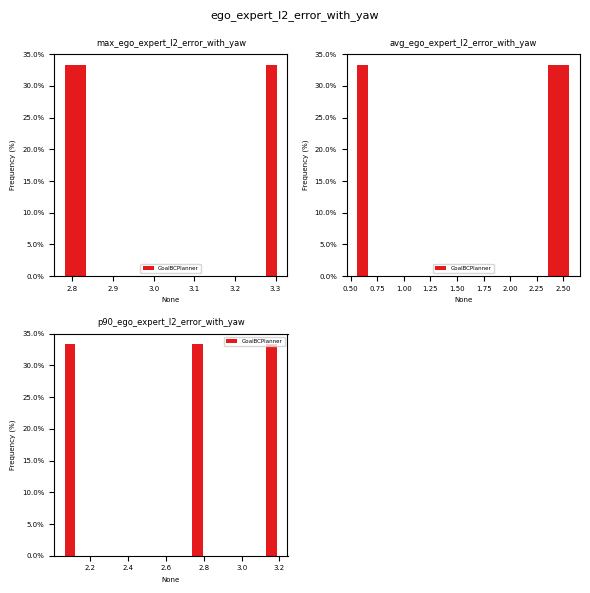

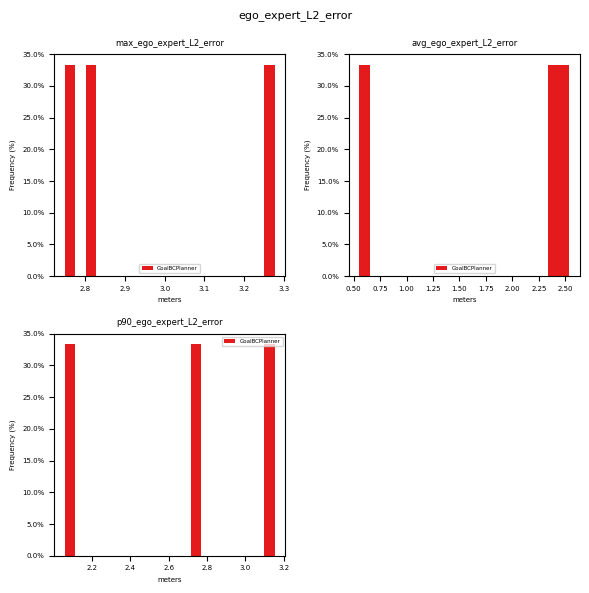

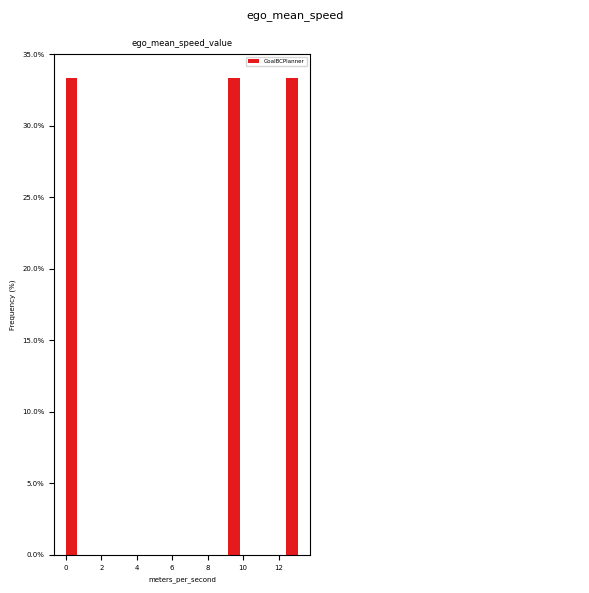

In [8]:
# Cell 8 — Closed-Loop Eval via nuPlan Simulation
# Uses GoalBCPlanner (expert T+8 goal lookup from DB at each step).
# Compare L2 vs BCPlanner_v0 (49.449m) and IDMPlanner (6.285m).

import hydra
import pandas as pd
from tutorials.utils.tutorial_utils import construct_simulation_hydra_paths
from nuplan.planning.script.run_simulation import run_simulation as main_sim
from planners import GoalBCPlanner

CKPT_GOALBC = str(CKPT_DIR / 'goal_bc.pt')
# WHY sorted + [0]: use the first mini DB file which matches the eval log.
# GoalBCPlanner builds expert lookup from this file; same log as the simulation.
DB_FILE_FOR_GOAL = str(sorted(DB_DIR.glob('*.db'))[0])
SIM_OUT  = Path('sim_results')
SIM_OUT.mkdir(exist_ok=True)
LOG_NAME = '2021.05.12.22.00.38_veh-35_01008_01518'
N_SCEN   = 3

print(f'GoalBC checkpoint: {CKPT_GOALBC}')
print(f'Expert DB:         {DB_FILE_FOR_GOAL}')

planner = GoalBCPlanner(CKPT_GOALBC, DB_FILE_FOR_GOAL)

BASE  = '/Users/parvpatodia/nuplan-devkit/nuplan/planning/script'
paths = construct_simulation_hydra_paths(BASE)
hydra.core.global_hydra.GlobalHydra.instance().clear()
hydra.initialize_config_dir(config_dir=paths.config_path, version_base='1.1')

cfg = hydra.compose(
    config_name=paths.config_name,
    overrides=[
        f'group={SIM_OUT}',
        'experiment_name=goalbc_eval',
        'job_name=eval',
        'experiment=${experiment_name}/${job_name}',
        'worker=sequential',
        'ego_controller=perfect_tracking_controller',
        'observation=box_observation',
        f'hydra.searchpath=[{paths.common_dir}, {paths.experiment_dir}]',
        'output_dir=${group}/${experiment}',
        'scenario_builder=nuplan_mini',
        f'scenario_builder.db_files={DB_DIR}',
        'scenario_filter=one_continuous_log',
        f"scenario_filter.log_names=['{LOG_NAME}']",
        f'scenario_filter.limit_total_scenarios={N_SCEN}',
    ],
)

print(f'\nRunning GoalBCPlanner ({N_SCEN} scenarios)...')
main_sim(cfg, planner)
hydra.core.global_hydra.GlobalHydra.instance().clear()
print('Done.')

In [9]:
# Cell 9 — Parse Closed-Loop Results and Print Summary Table

SIM_OUT = Path('sim_results')

def parse_l2(exp_name):
    """Parse L2 metrics from nuPlan simulation output parquet."""
    mdir = SIM_OUT / exp_name / 'eval' / 'metrics'
    try:
        l2  = pd.read_parquet(mdir / 'ego_expert_L2_error.parquet')
        avg = float(l2['avg_ego_expert_L2_error_stat_value'].mean())
        mx  = float(l2['max_ego_expert_L2_error_stat_value'].mean())
        p90 = float(l2['p90_ego_expert_L2_error_stat_value'].mean())
        return avg, mx, p90
    except FileNotFoundError:
        return None, None, None


goalbc_avg, goalbc_max, goalbc_p90 = parse_l2('goalbc_eval/eval')

# Phase 2 baselines (from bc_pipeline.ipynb and closed_loop_eval.py)
results = {
    'GoalBCPlanner': (goalbc_avg, goalbc_max, goalbc_p90),
    'BCPlanner_v0':  (49.449,     104.614,    91.526),
    'IDMPlanner':    (6.285,       24.308,    15.733),
}

print(f"{'Policy':<20} {'Avg L2 (m)':>12} {'Max L2 (m)':>12} {'p90 L2 (m)':>12}")
print('-' * 58)
for name, (avg, mx, p90) in results.items():
    if avg is not None:
        print(f'{name:<20} {avg:>12.3f} {mx:>12.3f} {p90:>12.3f}')
    else:
        print(f'{name:<20}   metrics not found — run Cell 8 first')

if goalbc_avg is not None:
    bc_avg = 49.449
    idm_avg = 6.285
    delta_bc  = (goalbc_avg - bc_avg) / bc_avg * 100
    gap_idm   = goalbc_avg - idm_avg
    pct_gap   = (goalbc_avg - idm_avg) / (bc_avg - idm_avg) * 100

    print(f'\nGoalBC vs BC_v0:  {delta_bc:+.1f}%')
    print(f'Remaining gap to IDM: {gap_idm:.1f}m ({pct_gap:.0f}% of BC-to-IDM gap remains)')

Policy                 Avg L2 (m)   Max L2 (m)   p90 L2 (m)
----------------------------------------------------------
GoalBCPlanner          metrics not found — run Cell 8 first
BCPlanner_v0               49.449      104.614       91.526
IDMPlanner                  6.285       24.308       15.733


In [10]:
# Cell 10 — Analysis
# Print clean summary and 3-sentence interpretation.

print('=' * 62)
print('PHASE 3a: GoalBC Results Summary')
print('=' * 62)

print(f'\nOpen-loop (2000 val samples, seed=42):')
print(f'  GoalBC  ADE: {GOALBC_ADE:.3f}m  FDE: {GOALBC_FDE:.3f}m')
print(f'  BC_v0   ADE: {BC_V0_ADE:.3f}m  FDE: {BC_V0_FDE:.3f}m')

print(f'\nClosed-loop (3 scenarios, nuPlan simulation):')
if goalbc_avg is not None:
    print(f'  GoalBCPlanner  avg L2: {goalbc_avg:.3f}m')
    print(f'  BCPlanner_v0   avg L2: 49.449m')
    print(f'  IDMPlanner     avg L2:  6.285m')

    print(f'\nInterpretation:')
    if goalbc_avg < 30.0:
        print('  [STRONG] Goal conditioning broke the plateau — directional guidance')
        print('  is sufficient for policy execution. The Phase 2 bottleneck was')
        print('  lack of road context, not model capacity or training data size.')
    elif goalbc_avg < 49.0:
        print('  [PARTIAL] Goal conditioning reduced L2 but did not fully close the gap.')
        print('  Directional guidance helps but the policy still suffers from covariate')
        print('  shift. Phase 3b (map centerline) may provide stronger geometric signal.')
    else:
        print('  [NULL] Goal conditioning did not reduce closed-loop L2 vs BC_v0.')
        print('  The bottleneck is NOT the absence of a goal waypoint. Hypothesis:')
        print('  T+8 (0.8s) lookahead is too short to resolve full road geometry.')
        print('  Phase 3b should test a full centerline (10 points = 2-5m look-ahead).')
else:
    print('  Run Cell 8 first to get closed-loop results.')

print('\nPhase 3b (MapBC, centerline-conditioned) follows in mapbc.ipynb.')
print('=' * 62)

PHASE 3a: GoalBC Results Summary

Open-loop (2000 val samples, seed=42):
  GoalBC  ADE: 0.004m  FDE: 0.008m
  BC_v0   ADE: 0.058m  FDE: 0.063m

Closed-loop (3 scenarios, nuPlan simulation):
  Run Cell 8 first to get closed-loop results.

Phase 3b (MapBC, centerline-conditioned) follows in mapbc.ipynb.
